In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import copy

from pyro_cases.utils.run_amortized_favi_with_fixed_design import train_and_test_amortized_favi_with_fixed_design
from pyro_cases.utils.run_non_amoretized_vae_with_fixed_design import train_and_test_non_amortized_vae_with_fixed_design
from pyro_cases.utils.run_mcmc_with_fixed_design import train_and_test_mcmc_with_fixed_design

In [3]:
device = torch.device("cuda:3")
task_name = "arm_electric_one_pred"
n_samples = 2000
seed = 123456
test_seed = 7272

In [4]:
def move_dict_to_device(pre_dict: dict, device):
    return {
        k: v.to(device=device) if isinstance(v, torch.Tensor) else v
        for k, v in pre_dict.items()
    }

In [5]:
deep_set_out_dict = train_and_test_amortized_favi_with_fixed_design(task_name=task_name,
                                                                    seed=seed,
                                                                    device=device,
                                                                    lr=1e-3,
                                                                    lr_schedule="cosine_annealing",
                                                                    batch_size=1024,
                                                                    network_width=256,
                                                                    steps=10_000,
                                                                    test_seed=test_seed,
                                                                    num_test_obs=1000,
                                                                    show_progress=True,
                                                                    return_vae=True,
                                                                    suppress_error=False,
                                                                    nn_type="deep_set")

100%|██████████| 10000/10000 [01:48<00:00, 92.34it/s]


[task arm_electric_one_pred seed 123456 completes] task start time: Sun Aug 17 15:14:55 2025; task end time: Sun Aug 17 15:16:43 2025; cost time: 108.4 seconds


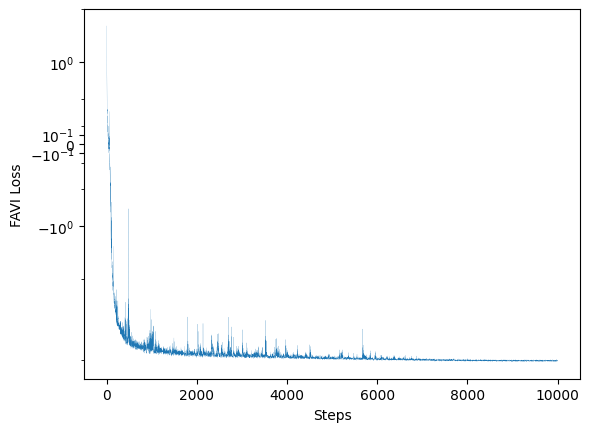

In [6]:
plt.plot(deep_set_out_dict["favi_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("FAVI Loss")
plt.yscale("asinh")
plt.show()

In [7]:
deep_set_samples = deep_set_out_dict["favi_vae_wrap"].variational_dist.draw_samples(
    deep_set_out_dict["favi_test_result_dict"]["raw_pred"],
    n_samples
)

In [8]:
deep_set_samples.shape

torch.Size([1000, 2, 2000])

In [9]:
deep_set_samples = deep_set_samples[0]

In [47]:
vae_out_dict = train_and_test_non_amortized_vae_with_fixed_design(task_name=task_name,
                                                                    seed=seed,
                                                                    device=device,
                                                                    lr=1e-1,
                                                                    num_particles=1,
                                                                    vectorize_particles=False,
                                                                    steps=10_000,
                                                                    test_seed=test_seed,
                                                                    num_test_obs=1000,
                                                                    show_progress=True,
                                                                    return_vae=True,
                                                                    suppress_error=False)

100%|██████████| 10000/10000 [02:09<00:00, 77.33it/s]

[task arm_electric_one_pred seed 123456 completes] task start time: Sun Aug 17 15:52:08 2025; task end time: Sun Aug 17 15:54:17 2025; cost time: 129.3 seconds


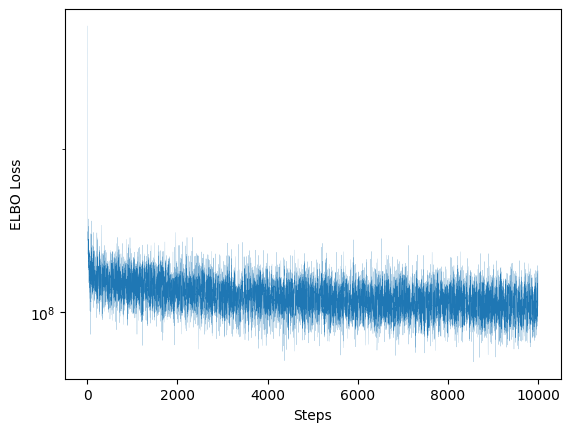

In [56]:
plt.plot(vae_out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("asinh")
plt.show()

In [57]:
vae_samples = vae_out_dict["elbo_vae"].variational_dist.draw_samples(
    vae_out_dict["elbo_test_result_dict"]["raw_pred"],
    n_samples
)

In [58]:
vae_samples.shape

torch.Size([1000, 2, 2000])

In [59]:
vae_samples = vae_samples[0]

In [30]:
deep_set_out_dict["favi_vae_wrap"].sample_dict_instr

{'meta_data': ['N'],
 'data': ['treatment', 'sigma'],
 'latent': OrderedDict([('beta',
               {'dist': pyro.distributions.torch.Independent,
                'constraint': IndependentConstraint(Real(), 1),
                'batch_shape': [1024],
                'event_shape': [2],
                'latent_size': 2,
                'plates': ['plate_batch']})]),
 'obs': OrderedDict([('post_test',
               {'dist': pyro.distributions.torch.Normal,
                'batch_shape': [50, 1024],
                'event_shape': [],
                'plates': ['plate_batch', 'plate_n']})])}

In [16]:
def extract_single_batch_test_sample_dict(test_sample_dict, sample_dict_instr, extract_i):
    new_test_sample_dict = copy.copy(test_sample_dict)
    for k, v in new_test_sample_dict.items():
        if k in sample_dict_instr["meta_data"]:
            continue
        if k in sample_dict_instr["data"] or k in sample_dict_instr["obs"]:
            new_test_sample_dict[k] = v[..., extract_i:(extract_i + 1)]
        elif k in sample_dict_instr["latent"]:
            event_ndim = len(sample_dict_instr["latent"][k]["event_shape"])
            assert event_ndim == 0 or event_ndim == 1
            if event_ndim == 0:
                new_test_sample_dict[k] = v[..., extract_i:(extract_i + 1)]
            else:
                new_test_sample_dict[k] = v[..., extract_i:(extract_i + 1), :]
        else:
            raise ValueError(f"can't find the key {k} in sample_dict_instr")
    return new_test_sample_dict

In [17]:
def test_eqaul(test_sample_dict1, test_sample_dict2):
    assert all([k in test_sample_dict2 for k in test_sample_dict1.keys()])
    for k, v in test_sample_dict1.items():
        if isinstance(v, torch.Tensor):
            assert torch.allclose(v, test_sample_dict2[k])
        else:
            assert v == test_sample_dict2[k]

In [18]:
single_b_test_sample_dict = extract_single_batch_test_sample_dict(deep_set_out_dict["favi_test_sample_dict"],
                                                                  deep_set_out_dict["favi_vae_wrap"].sample_dict_instr,
                                                                  extract_i=0)
another_test_sample_dict = extract_single_batch_test_sample_dict(vae_out_dict["elbo_test_sample_dict"],
                                                                  vae_out_dict["elbo_vae"].sample_dict_instr,
                                                                  extract_i=0)
test_eqaul(single_b_test_sample_dict, another_test_sample_dict)
single_b_test_sample_dict = move_dict_to_device(single_b_test_sample_dict, device=device)

In [19]:
mcmc_out_dict = train_and_test_mcmc_with_fixed_design(task_name=task_name,
                                                      seed=seed,
                                                      device=device,
                                                      test_sample_dict=single_b_test_sample_dict,
                                                      warmup_steps=500,
                                                      n_samples=n_samples)

Sample: 100%|██████████| 2500/2500 [01:16, 32.70it/s, step size=3.66e-01, acc. prob=0.916]

[task arm_electric_one_pred seed 123456 completes] task start time: Sun Aug 17 15:18:27 2025; task end time: Sun Aug 17 15:19:43 2025; cost time: 76.5 seconds


In [20]:
mcmc_out_dict["mcmc_samples"]["beta"].shape

torch.Size([2000, 1, 2])

In [21]:
mcmc_samples = mcmc_out_dict["mcmc_samples"]["beta"].squeeze(1).permute([1, 0])

In [31]:
deep_set_samples.shape, vae_samples.shape, mcmc_samples.shape

(torch.Size([2, 2000]), torch.Size([2, 2000]), torch.Size([2, 2000]))

In [60]:
def plot_marginal_comparison(favi_samples, vae_samples, mcmc_samples):
    assert favi_samples.shape[0] == mcmc_samples.shape[0]
    assert favi_samples.shape[0] == vae_samples.shape[0]
    ndim = favi_samples.shape[0]
    fig, axs = plt.subplots(nrows=ndim, ncols=3, figsize=(12, ndim * 4),
                            constrained_layout=True)
    for i, r_axes in enumerate(axs):
        sns.histplot(favi_samples[i], ax=r_axes[0], label="FAVI", kde=True, color="red")
        sns.histplot(vae_samples[i], ax=r_axes[1], label="VAE", kde=True, color="green")
        sns.histplot(mcmc_samples[i], ax=r_axes[2], label="MCMC", kde=True, color="blue")
        for ax in r_axes:
            ax.set_title(f"Param {i + 1}")
            ax.legend()
    fig.show()

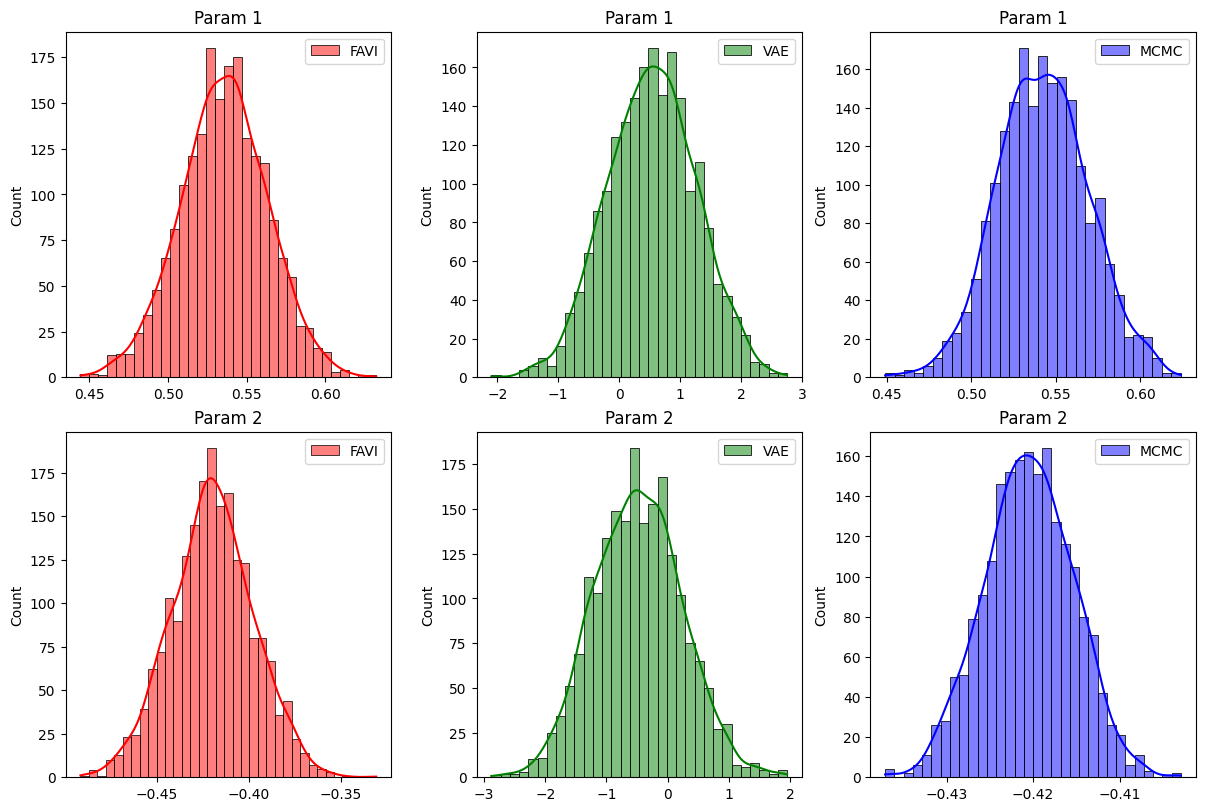

In [61]:
plot_marginal_comparison(deep_set_samples, vae_samples, mcmc_samples)

In [62]:
def plot_corr_comparison(favi_samples, vae_samples, mcmc_samples, param1_index, param2_index):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4),
                            constrained_layout=True)
    sns.kdeplot(x=favi_samples[param1_index], y=favi_samples[param2_index], ax=axs[0], fill=True, color="red", label="FAVI")
    axs[0].set_title("FAVI")
    sns.kdeplot(x=vae_samples[param1_index], y=vae_samples[param2_index], ax=axs[1], fill=True, color="green", label="VAE")
    axs[1].set_title("VAE")
    sns.kdeplot(x=mcmc_samples[param1_index], y=mcmc_samples[param2_index], ax=axs[2], fill=True, color="blue", label="MCMC")
    axs[2].set_title("MCMC")
    for ax in axs:
        ax.set(xlabel=f"Param {param1_index + 1}", ylabel=f"Param {param2_index + 1}")
    fig.show()

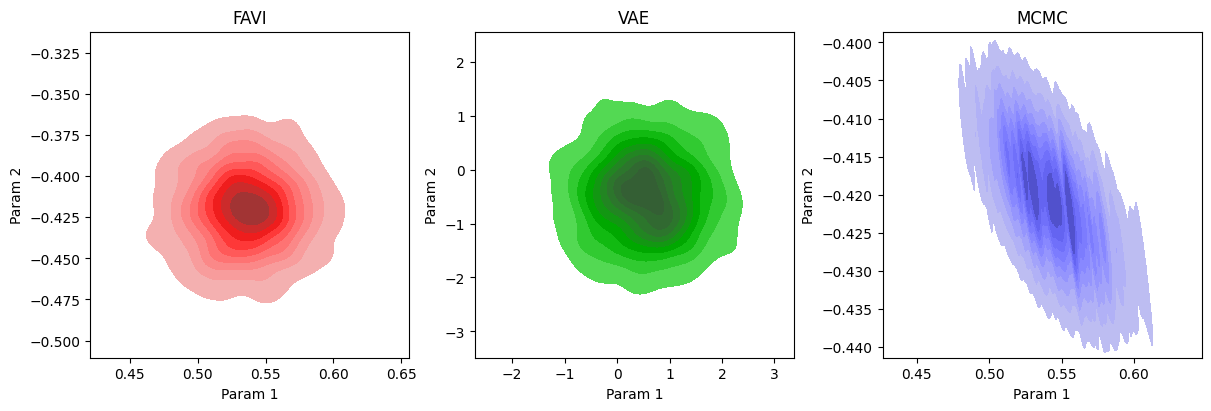

In [63]:
plot_corr_comparison(deep_set_samples, vae_samples, mcmc_samples, param1_index=0, param2_index=1)